# Singapore 2024 — Long-Run Data Visualization

This notebook visualizes FP2 and FP3 practice data to verify why the strategy analysis fails: **no usable long-run stints** for degradation curve fitting.

**Long-run criteria** (from `degradation_model.py`):
- Laps: `pick_accurate()` + `pick_wo_box()` + track status = "1" (green)
- Stint: ≥ 3 laps initially → strip first/last → need **5 laps** (SOFT) or **8 laps** (MED/HARD) remaining

In [1]:
import sys, os
# Run from f1_strategy folder so config can be imported
f1_dir = os.path.join(os.getcwd(), 'f1_strategy')
if os.path.exists(f1_dir):
    os.chdir(f1_dir)
sys.path.insert(0, os.getcwd())

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config import CACHE_DIR, COMPOUND_MIN_LONG_RUN, COMPOUNDS

fastf1.Cache.enable_cache(CACHE_DIR)

YEAR, GP = 2024, "Singapore"

In [2]:
# Load FP2 and FP3
fp2 = fastf1.get_session(YEAR, GP, "FP2")
fp3 = fastf1.get_session(YEAR, GP, "FP3")
fp2.load()
fp3.load()
print(f"Loaded: {fp2.event['EventName']} FP2, FP3")

core           INFO 	Loading data for Singapore Grand Prix - Practice 2 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '43', '44', '55', '63', '77', '81']
core           INFO 	Loading data for Singapore Grand Prix - Practice 3 [v3.8.1]
req            INFO 	Usin

Loaded: Singapore Grand Prix FP2, FP3


## 1. Raw lap counts & track status

In [3]:
def session_summary(session, name):
    laps = session.laps
    print(f"\n=== {name} ===")
    print(f"Total laps: {len(laps)}")
    print(f"Compounds: {laps['Compound'].dropna().unique().tolist()}")
    if 'TrackStatus' in laps.columns:
        ts = laps['TrackStatus'].astype(str).value_counts()
        print(f"Track status distribution:\n{ts}")
    print(f"Laps with IsAccurate=True: {laps['IsAccurate'].sum()}")
    print(f"Laps without pit (wo_box): {len(laps.pick_wo_box())}")
    clean = laps.pick_accurate().pick_wo_box()
    try:
        green = clean.pick_track_status('1', how='equals')
        print(f"After filters (accurate + wo_box + green): {len(green)}")
    except Exception:
        print(f"After filters (accurate + wo_box): {len(clean)} (track_status filter skipped)")

session_summary(fp2, "FP2")
session_summary(fp3, "FP3")


=== FP2 ===
Total laps: 521
Compounds: ['HARD', 'SOFT', 'MEDIUM']
Track status distribution:
TrackStatus
1     378
12     77
2      49
21     17
Name: count, dtype: int64
Laps with IsAccurate=True: 319
Laps without pit (wo_box): 356
After filters (accurate + wo_box + green): 226

=== FP3 ===
Total laps: 355
Compounds: ['MEDIUM', 'SOFT', 'HARD']
Track status distribution:
TrackStatus
1     333
12     20
15      2
Name: count, dtype: int64
Laps with IsAccurate=True: 162
Laps without pit (wo_box): 204
After filters (accurate + wo_box + green): 159


## 2. Stint analysis — what qualifies as a long run?

In [4]:
def analyze_stints(session, name):
    laps = session.laps
    clean = laps.pick_accurate().pick_wo_box()
    try:
        clean = clean.pick_track_status("1", how="equals")
    except Exception:
        pass
    
    stints = []
    for driver in clean["Driver"].unique():
        driver_laps = clean.pick_drivers(driver)
        for stint_num in driver_laps["Stint"].unique():
            stint = driver_laps[driver_laps["Stint"] == stint_num].copy()
            stint = stint.sort_values("LapNumber")
            n = len(stint)
            if n < 3:
                continue
            after_strip = n - 2  # strip first and last
            compound = stint["Compound"].iloc[0]
            min_req = COMPOUND_MIN_LONG_RUN.get(compound, 5)
            qualifies = compound in COMPOUNDS and after_strip >= min_req
            stints.append({
                "session": name,
                "driver": driver,
                "compound": compound,
                "laps_raw": n,
                "laps_after_strip": after_strip,
                "min_required": min_req,
                "qualifies": qualifies,
            })
    return pd.DataFrame(stints)

df_fp2 = analyze_stints(fp2, "FP2")
df_fp3 = analyze_stints(fp3, "FP3")
df_all = pd.concat([df_fp2, df_fp3], ignore_index=True)

print("All stints (≥3 laps after filters):")
display(df_all)
print(f"\nStints that QUALIFY as long runs: {df_all['qualifies'].sum()}")
print(f"Stints that do NOT qualify: {(~df_all['qualifies']).sum()}")

All stints (≥3 laps after filters):


,session,driver,compound,laps_raw,laps_after_strip,min_required,qualifies
0,FP2,VER,HARD,3,1,8,False
1,FP2,VER,HARD,4,2,8,False
2,FP2,RIC,MEDIUM,8,6,8,False
3,FP2,NOR,HARD,3,1,8,False
4,FP2,NOR,SOFT,6,4,5,False
...,...,...,...,...,...,...,...
60,FP3,SAI,MEDIUM,4,2,8,False
61,FP3,SAI,MEDIUM,3,1,8,False
62,FP3,RUS,MEDIUM,3,1,8,False
63,FP3,BOT,SOFT,4,2,5,False



Stints that QUALIFY as long runs: 0
Stints that do NOT qualify: 65


## 3. Visualization — stint lengths by compound

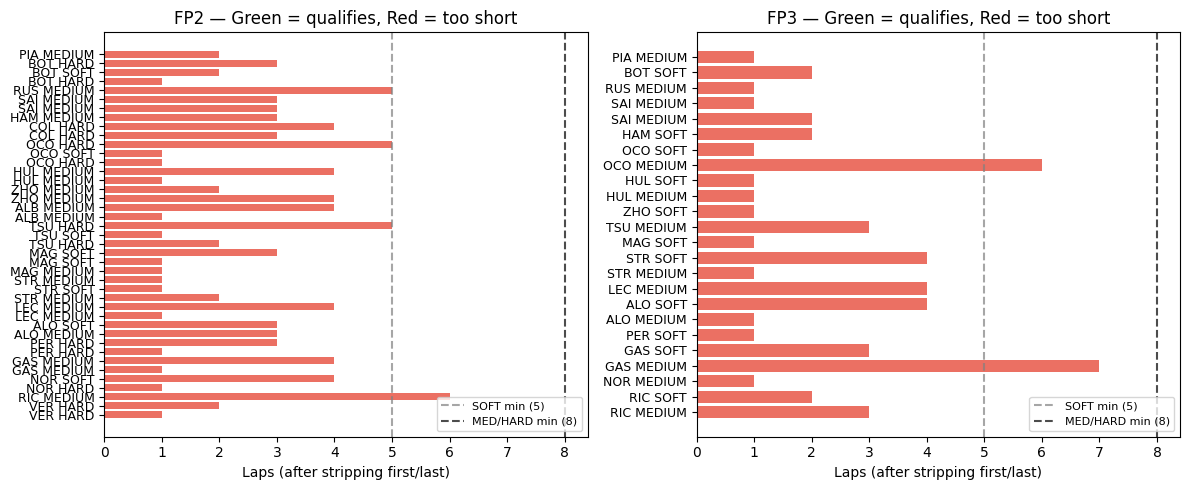

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (session, df) in zip(axes, [("FP2", df_fp2), ("FP3", df_fp3)]):
    if df.empty:
        ax.text(0.5, 0.5, f"No stints in {session}", ha='center', va='center')
        continue
    colors = ['#2ecc71' if q else '#e74c3c' for q in df['qualifies']]
    bars = ax.barh(range(len(df)), df['laps_after_strip'], color=colors, alpha=0.8)
    ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='SOFT min (5)')
    ax.axvline(x=8, color='black', linestyle='--', alpha=0.7, label='MED/HARD min (8)')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f"{r['driver']} {r['compound']}" for _, r in df.iterrows()], fontsize=9)
    ax.set_xlabel('Laps (after stripping first/last)')
    ax.set_title(f'{session} — Green = qualifies, Red = too short')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Track status distribution (why laps get filtered)

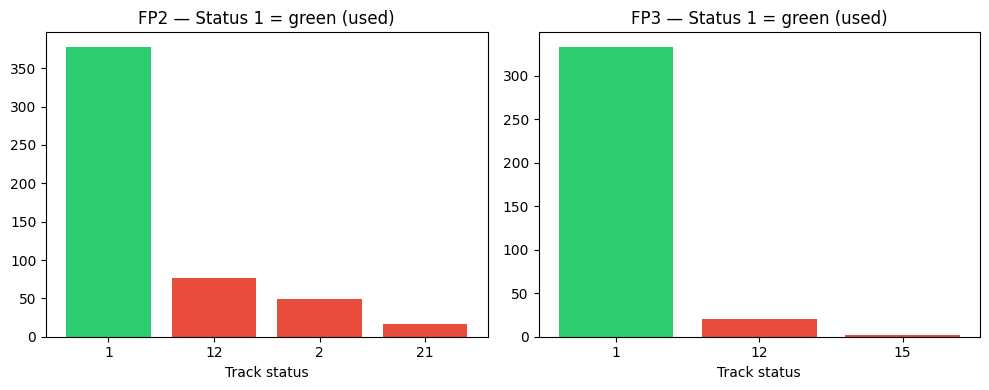

In [6]:
# Only laps with TrackStatus='1' (green) are used. Yellow/red/safety car = excluded.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (session, name) in zip(axes, [(fp2, 'FP2'), (fp3, 'FP3')]):
    laps = session.laps
    if 'TrackStatus' in laps.columns:
        ts = laps['TrackStatus'].astype(str).value_counts().sort_index()
        colors = ['#2ecc71' if str(k) == '1' else '#e74c3c' for k in ts.index]
        ax.bar(ts.index.astype(str), ts.values, color=colors)
        ax.set_title(f'{name} — Status 1 = green (used)')
    ax.set_xlabel('Track status')
plt.tight_layout()
plt.show()

## 5. Conclusion

In [7]:
qualifying = df_all[df_all['qualifies']]
print("Summary:")
print(f"  Total stints analyzed: {len(df_all)}")
print(f"  Stints qualifying as long runs: {len(qualifying)}")
if qualifying.empty:
    print("\n  → No degradation curves can be built.")
    print("  → Singapore 2024 had disrupted FP2/FP3 (red flags, rain).")
    print("  → Teams did mostly short runs; no stint meets min laps (5 SOFT, 8 MED/HARD).")

Summary:
  Total stints analyzed: 65
  Stints qualifying as long runs: 0

  → No degradation curves can be built.
  → Singapore 2024 had disrupted FP2/FP3 (red flags, rain).
  → Teams did mostly short runs; no stint meets min laps (5 SOFT, 8 MED/HARD).
